# Part 2: Unsupervised Learning Activity

**Group members:** Ahammad Jony, Kumara Muditha, Podkorytov Nikolai, Shrestha Bata Prabesh

This notebook demonstrates clustering and dimensionality reduction on an unlabeled dataset. In here done model comparison, visualizations, and ethical/practical reflections.

## 1) Problem Statement and Dataset Choice

We aim to discover natural groups in data without using labels and evaluate.

### Selected dataset
We use the **Wine dataset** from `scikit-learn` because:
- It is reliable and available locally (no external download needed).
- It has multiple numerical features suitable for distance-based clustering.
- It is commonly used for unsupervised learning demonstrations.

For unsupervised learning, the true class label is **not used for training**.

In [12]:
# 2) Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style='whitegrid', context='notebook')
np.random.seed(42)

## 2) Load Data and Basic Inspection

We load feature data and keep only the numeric predictors for clustering.

In [13]:
# Load dataset as a DataFrame
wine = load_wine(as_frame=True)
df = wine.frame.copy()

# Remove target for unsupervised learning
X = df.drop(columns=['target'])

print(f'Shape of feature matrix: {X.shape}')
display(X.head())

Shape of feature matrix: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3) Data Quality Checks and Preprocessing

We verify missing values and apply `StandardScaler`. So that all features contribute fairly to distance-based clustering methods.

In [14]:
# Check missing values and duplicates
missing_counts = X.isnull().sum().sum()
duplicate_count = X.duplicated().sum()

print(f'Total missing values: {missing_counts}')
print(f'Duplicate rows: {duplicate_count}')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.describe().T[['mean', 'std']].head())

Total missing values: 0
Duplicate rows: 0


,mean,std
alcohol,-8.382808e-16,1.002821
malic_acid,-1.197544e-16,1.002821
ash,-8.370333e-16,1.002821
alcalinity_of_ash,-3.991813e-17,1.002821
magnesium,-3.991813e-17,1.002821


## 4) Clustering Model 1: K-Means

### Hyperparameter tuning
We tune `n_clusters` using:
- **Elbow method** (inertia)
- **Silhouette score**

The final `k` is selected using the best silhouette score and elbow interpretability.

Best k by silhouette score: 3


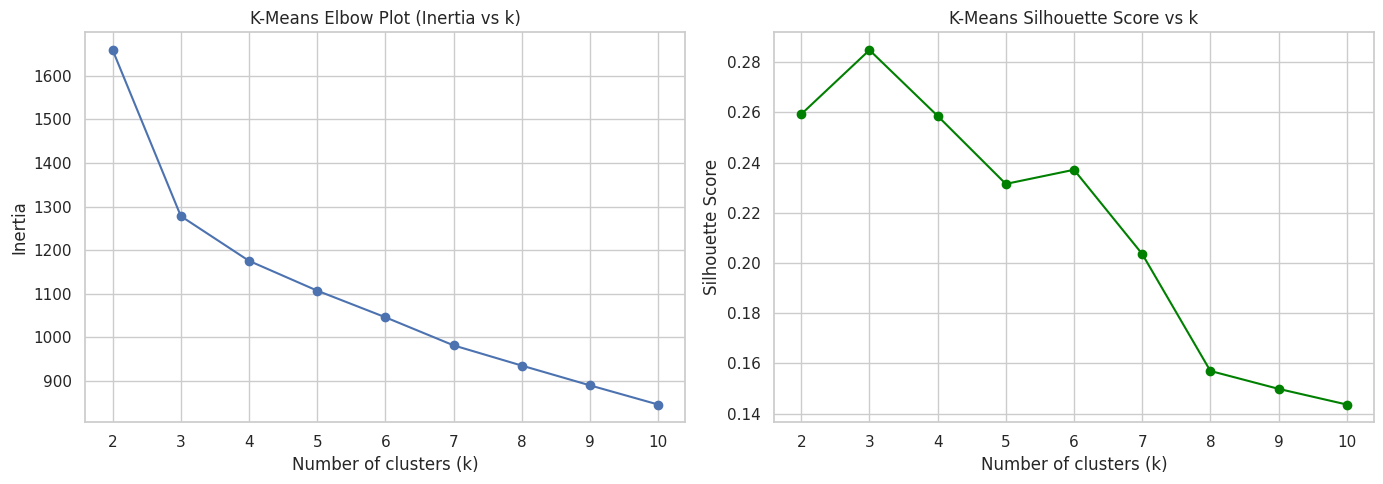

In [15]:
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

best_k = int(k_values[np.argmax(silhouette_scores)])
print(f'Best k by silhouette score: {best_k}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertia_scores, marker='o')
axes[0].set_title('K-Means Elbow Plot (Inertia vs k)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_values), silhouette_scores, marker='o', color='green')
axes[1].set_title('K-Means Silhouette Score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

### Train final K-Means model and visualize clusters

We project data to 2D using PCA for visualization and plot cluster centroids.

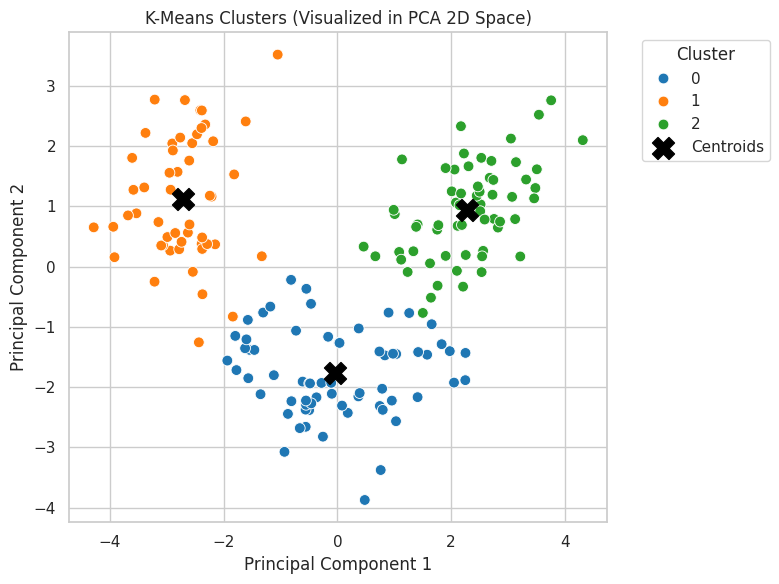

In [16]:
# Fit final K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 2D PCA projection for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=kmeans_labels, palette='tab10', s=60)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='black', s=250, marker='X', label='Centroids')
plt.title('K-Means Clusters (Visualized in PCA 2D Space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5) Clustering Model 2: Hierarchical (Agglomerative) Clustering

### Hyperparameter tuning
We tune the number of clusters (`n_clusters`) and evaluate each candidate using:
- **Silhouette score**
- **Davies-Bouldin index**

We also use a **dendrogram** to visualize hierarchical merges and support cluster-count interpretation.

In [17]:
candidate_clusters = range(2, 11)
agglo_results = []

for n in candidate_clusters:
    agg = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)

    agglo_results.append({
        'n_clusters': int(n),
        'silhouette': sil,
        'davies_bouldin': dbi
    })

agglo_df = pd.DataFrame(agglo_results).sort_values(by='silhouette', ascending=False)
display(agglo_df)

best_n_clusters = int(agglo_df.iloc[0]['n_clusters'])
print(f'Best n_clusters for Agglomerative (by silhouette): {best_n_clusters}')

,n_clusters,silhouette,davies_bouldin
1,3,0.277444,1.418592
0,2,0.267013,1.411757
2,4,0.225837,1.788651
8,10,0.198568,1.475509
7,9,0.191717,1.545154
6,8,0.188347,1.551358
5,7,0.186853,1.661616
3,5,0.186742,1.922855
4,6,0.179666,1.812288


Best n_clusters for Agglomerative (by silhouette): 3


### Dendrogram and final Hierarchical model visualization

The dendrogram shows merge distances between observations. Then we train the final Agglomerative model using the best `n_clusters` from metric tuning.

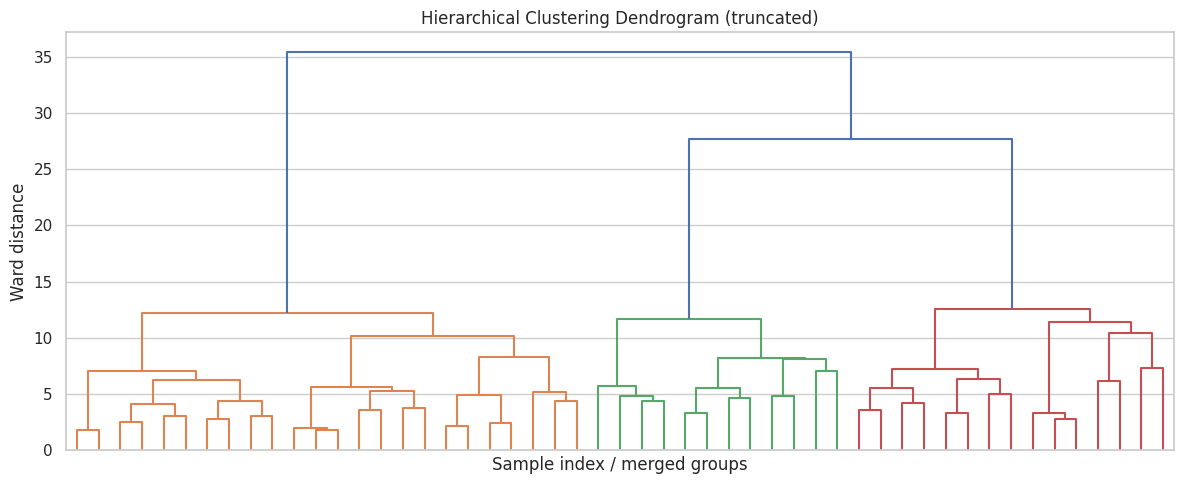

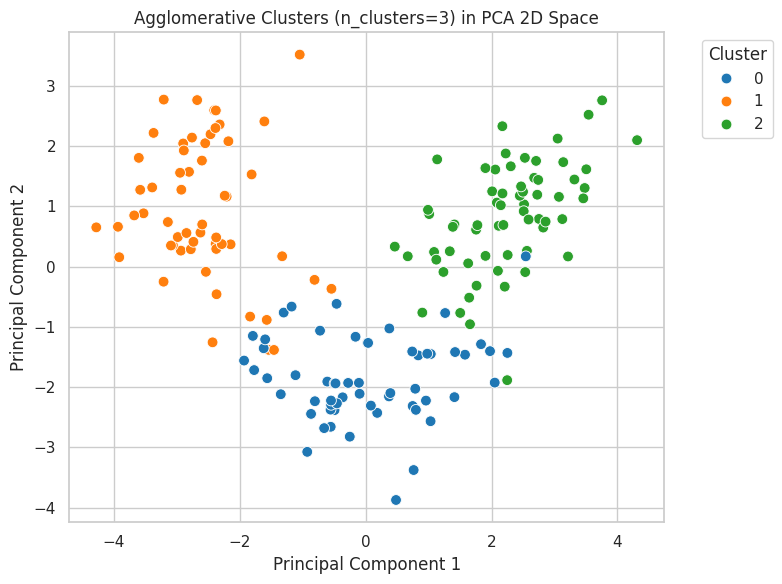

In [18]:
# Dendrogram (Ward linkage)
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=5, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Sample index / merged groups')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()

# Final Agglomerative model
agglomerative = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
agglomerative_labels = agglomerative.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=agglomerative_labels, palette='tab10', s=60)
plt.title(f'Agglomerative Clusters (n_clusters={best_n_clusters}) in PCA 2D Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6) Quantitative Model Comparison

We compare K-Means and Agglomerative Clustering using:
- **Silhouette Score** (higher is better)
- **Davies-Bouldin Index** (lower is better)

In [19]:
def evaluate_general(data, labels):
    unique_eval = np.unique(labels)
    if len(unique_eval) < 2 or len(labels) < 3:
        return np.nan, np.nan

    sil = silhouette_score(data, labels)
    dbi = davies_bouldin_score(data, labels)
    return sil, dbi

kmeans_sil, kmeans_dbi = evaluate_general(X_scaled, kmeans_labels)
agglo_sil, agglo_dbi = evaluate_general(X_scaled, agglomerative_labels)

comparison_df = pd.DataFrame([
    {
        'Model': 'K-Means',
        'Best Hyperparameters': f'k={best_k}',
        'Silhouette Score': kmeans_sil,
        'Davies-Bouldin Index': kmeans_dbi
    },
    {
        'Model': 'Agglomerative (Hierarchical)',
        'Best Hyperparameters': f'n_clusters={best_n_clusters}, linkage=ward',
        'Silhouette Score': agglo_sil,
        'Davies-Bouldin Index': agglo_dbi
    }
])

display(comparison_df)

,Model,Best Hyperparameters,Silhouette Score,Davies-Bouldin Index
0,K-Means,k=3,0.284859,1.389188
1,Agglomerative (Hierarchical),"n_clusters=3, linkage=ward",0.277444,1.418592


## 7) Dimensionality Reduction with PCA

Requirement: choose the optimal number of components to explain at least **85%** variance, and visualize data in 2D.

We compute cumulative explained variance and identify the minimum number of principal components needed to cross 85%.

Minimum components for >=85% explained variance: 6
Explained variance ratio (first 2 PCs): [0.36198848 0.1920749 ]
Cumulative explained variance with 2 components: 0.5541


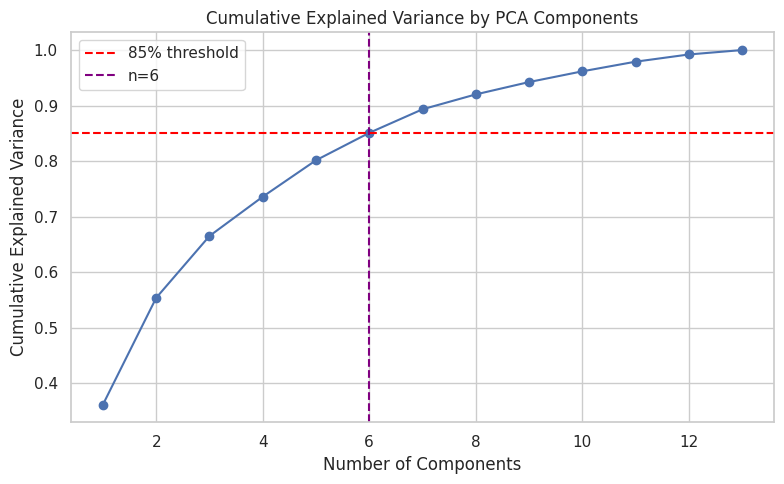

In [20]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

n_components_85 = int(np.argmax(cum_explained_var >= 0.85) + 1)
print(f'Minimum components for >=85% explained variance: {n_components_85}')
print(f'Explained variance ratio (first 2 PCs): {explained_var[:2]}')
print(f'Cumulative explained variance with 2 components: {cum_explained_var[1]:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker='o')
plt.axhline(0.85, color='red', linestyle='--', label='85% threshold')
plt.axvline(n_components_85, color='purple', linestyle='--', label=f'n={n_components_85}')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

### PCA 2D Cluster Visualization

Even if more than 2 components are needed for 85% variance, 2D PCA remains useful for visual interpretation.

Below, we compare K-Means and Agglomerative labels in PCA 2D space.

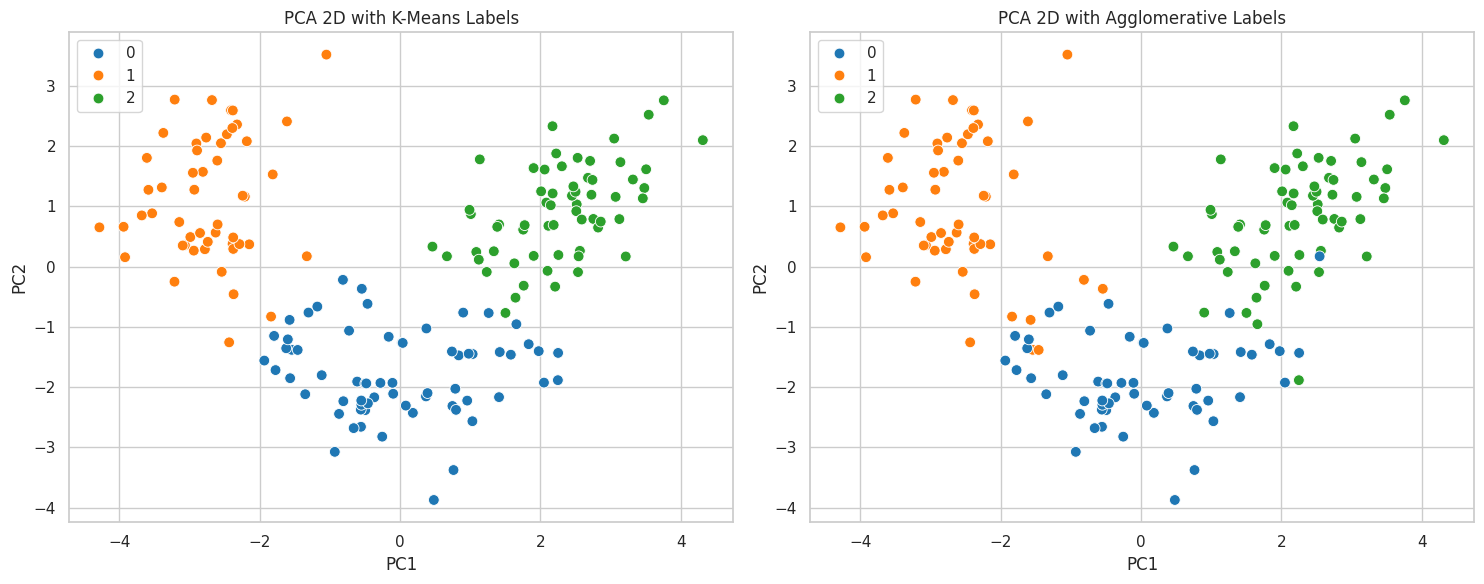

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=kmeans_labels, palette='tab10', s=60, ax=axes[0])
axes[0].set_title('PCA 2D with K-Means Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=agglomerative_labels, palette='tab10', s=60, ax=axes[1])
axes[1].set_title('PCA 2D with Agglomerative Labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 8) Optional: t-SNE for Non-Linear Structure

t-SNE can reveal non-linear local neighborhood structure and is useful as a visual companion to PCA.

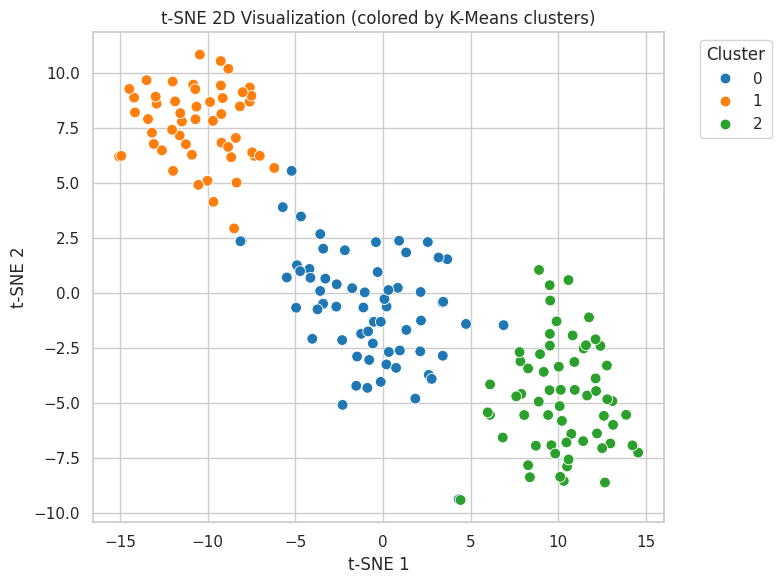

In [22]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette='tab10', s=60)
plt.title('t-SNE 2D Visualization (colored by K-Means clusters)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9) Comparative Analysis and Insights

### How clustering and PCA complement each other
- Clustering assigns group structure in feature space.
- PCA provides an interpretable 2D projection to inspect separation/overlap.
- Together, they enable both quantitative and visual validation.

### Practical challenges observed
- K-Means requires careful choice of `k`.
- Agglomerative clustering requires selecting linkage strategy and cluster cutoff.
- A 2D projection may not capture all high-dimensional structure.

### Example real-world applications
- Customer segmentation for targeted campaigns
- Fraud pattern exploration in transactions
- Grouping similar products/documents in recommendation systems

## 10) Ethical and Practical Considerations

### Ethical risks
- **Bias:** Non-representative data can produce unfair clusters.
- **Privacy:** Behavioral or profile-based clustering may expose sensitive patterns.
- **Misinterpretation:** Clusters are model-generated patterns, not absolute truths.

### Mitigation strategies
- Apply anonymization and data minimization.
- Audit input data representativeness and update periodically.
- Report assumptions, limitations, and uncertainty transparently.

### Feasibility reflection
- This workflow is computationally feasible on standard laptops for small to medium datasets.
- Production deployment requires domain features, monitoring, and human-in-the-loop validation.